# Tabular Q-Learning for Turbofan RUL (Offline RL)

## Problem Framing

We cast predictive-maintenance as an **offline RL** problem:

| RL concept | Turbofan mapping |
|-----------|------------------|
| State  `s` | Discretised health-index bucket (0–N) at current cycle |
| Action `a` | 0 = *continue running*, 1 = *flag for maintenance* |
| Reward `r` | Shaped from ground-truth RUL (see §3) |
| Episode    | One engine's operational life (from cycle 1 → failure) |
| Offline    | We learn from the static CMAPSS log; no simulator interaction |

State representation: we reduce the high-dimensional sensor space to a **1-D health index**  
via PCA → scalar score, then bin into `N_STATES` discrete buckets.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from collections import defaultdict

sns.set_theme(style='darkgrid')
np.random.seed(42)

DATA_DIR = Path('../data/CMaps')

# ── Constants (aligned with 01_eda.ipynb) ──────────────────────────────────
INDEX_COLS   = ['unit', 'cycle']
SETTING_COLS = ['setting_1', 'setting_2', 'setting_3']
SENSOR_COLS  = [f's_{i}' for i in range(1, 22)]
ALL_COLS     = INDEX_COLS + SETTING_COLS + SENSOR_COLS
DEAD_SENSORS = ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
LIVE_SENSORS = [s for s in SENSOR_COLS if s not in DEAD_SENSORS]
RUL_CAP      = 125
W            = 30   # rolling-average window

# ── Q-learning hyper-parameters ────────────────────────────────────────────
N_STATES     = 20   # health-index buckets
N_ACTIONS    = 2    # 0=continue, 1=flag
ALPHA        = 0.1  # learning rate
GAMMA        = 0.95 # discount
EPSILON      = 0.1  # ε-greedy (offline: fixed, no true exploration)
N_EPOCHS     = 50   # passes over the dataset

## 1. Data Loading & Preprocessing

In [3]:
def load_train(fd_id=1):
    df = pd.read_csv(DATA_DIR / f'train_FD00{fd_id}.txt',
                     sep=r'\s+', header=None, names=ALL_COLS, index_col=False)
    max_cycle = df.groupby('unit')['cycle'].max().rename('max_cycle')
    df = df.merge(max_cycle, on='unit')
    df['RUL'] = (df['max_cycle'] - df['cycle']).clip(upper=RUL_CAP)
    df.drop(columns='max_cycle', inplace=True)
    return df

train = load_train(fd_id=1)

# Rolling-mean smoothing per unit
for s in LIVE_SENSORS:
    train[s] = (train.groupby('unit')[s]
                     .transform(lambda x: x.rolling(W, min_periods=1).mean()))

# Normalise to [0, 1]
scaler = MinMaxScaler()
train[LIVE_SENSORS] = scaler.fit_transform(train[LIVE_SENSORS])

print('Train shape:', train.shape)
train.head()

Train shape: (20631, 27)


,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,0.170063,0.562519,0.335837,14.62,...,0.256898,0.218018,0.488517,0.03,0.329670,2388,100.0,0.737937,0.740470,125
1,1,2,0.0019,-0.0003,100.0,518.67,0.245902,0.598267,0.368100,14.62,...,0.328259,0.191440,0.522199,0.03,0.329670,2388,100.0,0.700499,0.745620,125
2,1,3,-0.0043,0.0003,100.0,518.67,0.301823,0.567128,0.387830,14.62,...,0.313987,0.186905,0.507868,0.03,0.219780,2388,100.0,0.667221,0.688071,125
3,1,4,0.0007,0.0000,100.0,518.67,0.329784,0.507717,0.382897,14.62,...,0.342531,0.185755,0.432792,0.03,0.247253,2388,100.0,0.628744,0.675924,125
4,1,5,-0.0019,-0.0002,100.0,518.67,0.348399,0.472475,0.402039,14.62,...,0.336822,0.185021,0.454781,0.03,0.296703,2388,100.0,0.610649,0.682294,125


## 2. State Discretisation via PCA → Health Index

PCA variance explained: 0.892
Health–RUL correlation : 0.760


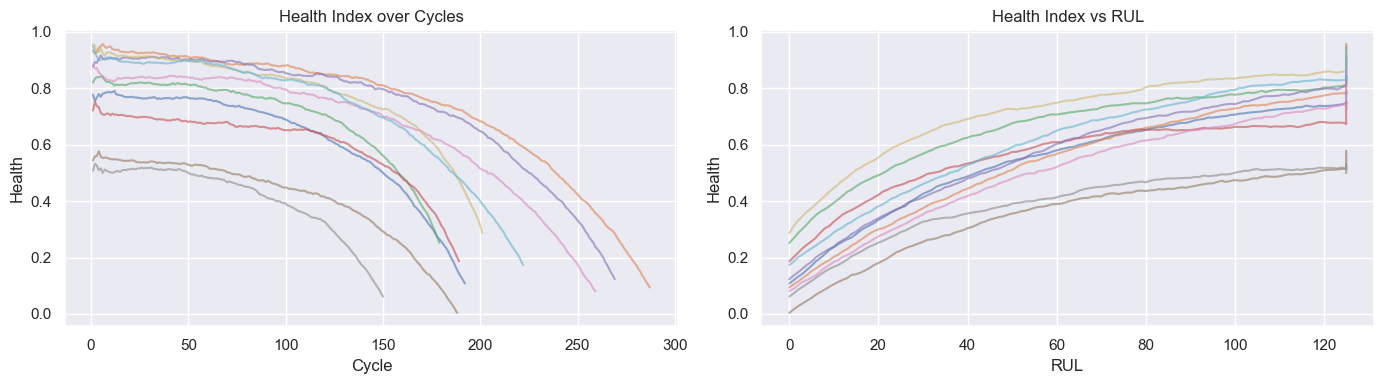

In [4]:
pca = PCA(n_components=1)
health_raw = pca.fit_transform(train[LIVE_SENSORS]).ravel()

# Rescale health index to [0, 1]  (higher = healthier)
h_min, h_max = health_raw.min(), health_raw.max()
health_norm = (health_raw - h_min) / (h_max - h_min + 1e-9)

# Flip sign if health decreases with RUL (should positively correlate with RUL)
if np.corrcoef(health_norm, train['RUL'])[0, 1] < 0:
    health_norm = 1.0 - health_norm

train['health'] = health_norm
train['state']  = (health_norm * (N_STATES - 1)).astype(int).clip(0, N_STATES - 1)

print(f'PCA variance explained: {pca.explained_variance_ratio_[0]:.3f}')
print(f'Health–RUL correlation : {np.corrcoef(health_norm, train["RUL"])[0,1]:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Sample a few engines
sample_units = train['unit'].unique()[:10]
for uid in sample_units:
    e = train[train['unit'] == uid]
    axes[0].plot(e['cycle'], e['health'], alpha=0.6)
    axes[1].plot(e['RUL'],   e['health'], alpha=0.6)
axes[0].set(title='Health Index over Cycles', xlabel='Cycle', ylabel='Health')
axes[1].set(title='Health Index vs RUL', xlabel='RUL', ylabel='Health')
plt.tight_layout()
plt.show()

## 3. Reward Function Design

| Action | RUL zone       | Reward |
|--------|---------------|--------|
| 0 (continue) | RUL > threshold | +1 (correct — engine is fine) |
| 0 (continue) | RUL ≤ threshold | −10 (missed fault → catastrophic) |
| 1 (flag) | RUL > threshold | −3 (false alarm → unnecessary downtime) |
| 1 (flag) | RUL ≤ threshold | +5 (correct early warning) |

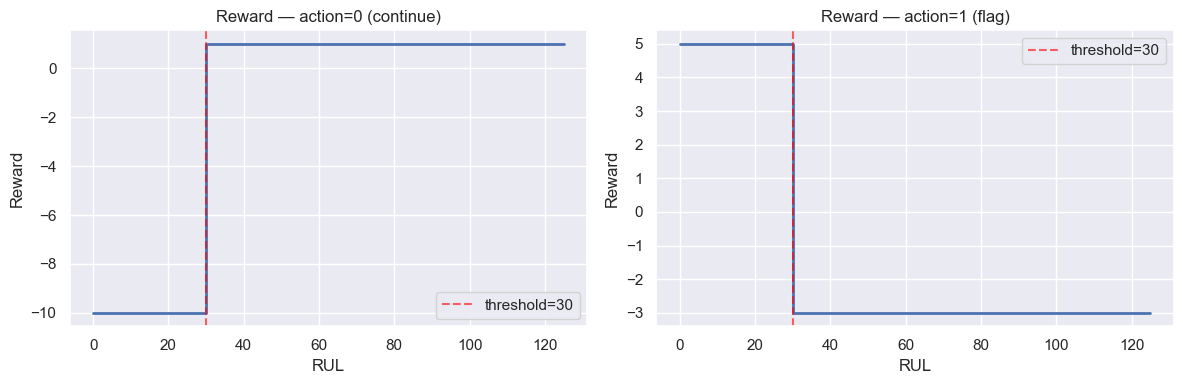

In [5]:
FLAG_THRESHOLD = 30  # cycles — flag when RUL ≤ this value

def reward(action: int, rul: float) -> float:
    near_failure = rul <= FLAG_THRESHOLD
    if action == 0 and not near_failure: return  1.0
    if action == 0 and near_failure:     return -10.0
    if action == 1 and not near_failure: return -3.0
    if action == 1 and near_failure:     return  5.0

# Visualise reward landscape
rul_vals = np.arange(0, RUL_CAP + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for a, ax in zip([0, 1], axes):
    r_vals = [reward(a, r) for r in rul_vals]
    ax.step(rul_vals, r_vals, linewidth=2)
    ax.axvline(FLAG_THRESHOLD, color='red', linestyle='--', alpha=0.6, label=f'threshold={FLAG_THRESHOLD}')
    ax.set(title=f'Reward — action={a} ({"continue" if a==0 else "flag"})',
           xlabel='RUL', ylabel='Reward')
    ax.legend()
plt.tight_layout()
plt.show()

## 4. Build Offline Transitions

Each row in the dataset becomes a `(s, a_behaviour, r, s')` tuple.  
Since this is **offline RL**, we do not choose actions — we label each step with the  
*optimal* action under the reward function (supervised signal), then learn Q from that.

In [6]:
transitions = []  # list of (state, action, reward, next_state, done)

for uid, episode in train.groupby('unit'):
    episode = episode.reset_index(drop=True)
    for i in range(len(episode) - 1):
        s  = int(episode.loc[i,   'state'])
        s_ = int(episode.loc[i+1, 'state'])
        rul_i = float(episode.loc[i, 'RUL'])
        # Optimal action (used as behaviour action in offline setting)
        a = 1 if rul_i <= FLAG_THRESHOLD else 0
        r = reward(a, rul_i)
        done = (i == len(episode) - 2)
        transitions.append((s, a, r, s_, done))

print(f'Total transitions: {len(transitions):,}')

Total transitions: 20,531


## 5. Tabular Q-Learning (Fitted Q-Iteration on Offline Data)

Final MSE loss (epoch 50): 14.2851


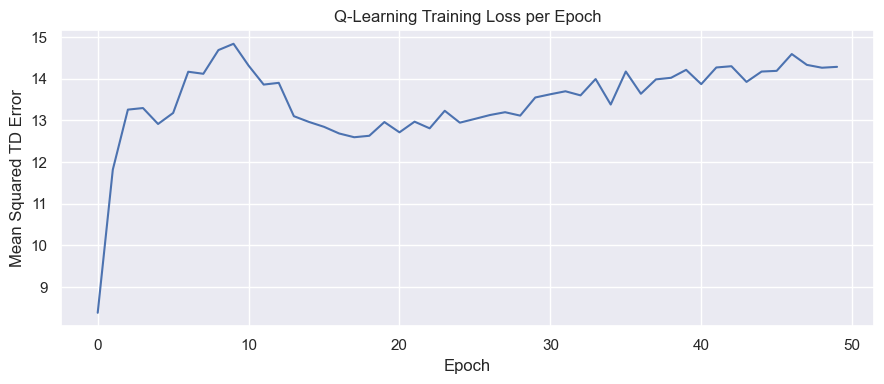

In [7]:
Q = np.zeros((N_STATES, N_ACTIONS))

epoch_losses = []

for epoch in range(N_EPOCHS):
    total_loss = 0.0
    np.random.shuffle(transitions)   # type: ignore
    for s, a, r, s_, done in transitions:
        target = r if done else r + GAMMA * Q[s_].max()
        error  = target - Q[s, a]
        Q[s, a] += ALPHA * error
        total_loss += error ** 2
    epoch_losses.append(total_loss / len(transitions))

print(f'Final MSE loss (epoch {N_EPOCHS}): {epoch_losses[-1]:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(epoch_losses)
plt.title('Q-Learning Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared TD Error')
plt.tight_layout()
plt.show()

## 6. Inspect the Learned Q-Table

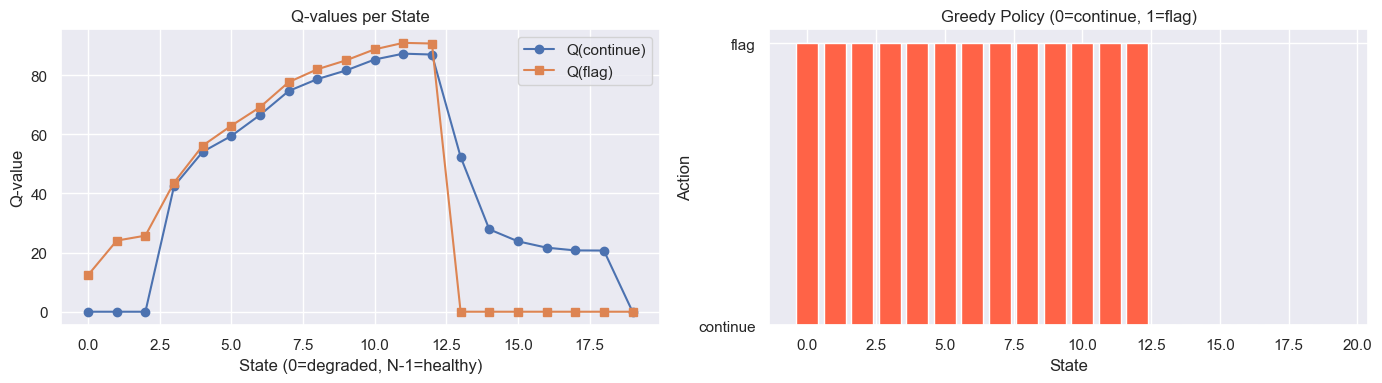

Policy switches to FLAG at state ≤ 0 (out of 20)


In [8]:
Q_df = pd.DataFrame(Q, columns=['Q(continue)', 'Q(flag)'])
Q_df.index.name = 'state'
Q_df['policy'] = Q.argmax(axis=1)
Q_df['policy_label'] = Q_df['policy'].map({0: 'continue', 1: 'flag'})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(Q_df.index, Q_df['Q(continue)'], marker='o', label='Q(continue)')
axes[0].plot(Q_df.index, Q_df['Q(flag)'],     marker='s', label='Q(flag)')
axes[0].set(title='Q-values per State', xlabel='State (0=degraded, N-1=healthy)', ylabel='Q-value')
axes[0].legend()

policy_colors = Q_df['policy'].map({0: 'steelblue', 1: 'tomato'})
axes[1].bar(Q_df.index, Q_df['policy'], color=policy_colors)
axes[1].set(title='Greedy Policy (0=continue, 1=flag)', xlabel='State', ylabel='Action')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['continue', 'flag'])

plt.tight_layout()
plt.show()

# First state where policy switches to "flag"
flag_state = Q_df[Q_df['policy'] == 1].index.min()
print(f'Policy switches to FLAG at state ≤ {flag_state} (out of {N_STATES})')

## 7. Evaluate on Test Set

=== Classification Report (flag vs continue, last cycle per unit) ===
              precision    recall  f1-score   support

    continue       1.00      0.37      0.54        75
        flag       0.35      1.00      0.52        25

    accuracy                           0.53       100
   macro avg       0.67      0.69      0.53       100
weighted avg       0.84      0.53      0.54       100



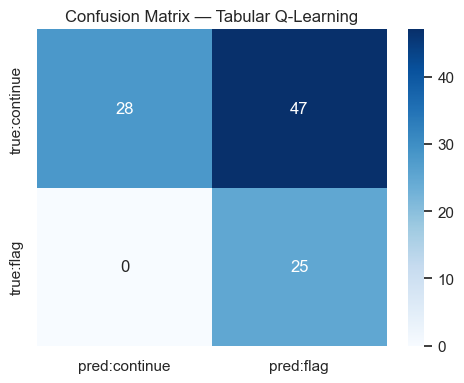

In [9]:
def load_test(fd_id=1):
    test = pd.read_csv(DATA_DIR / f'test_FD00{fd_id}.txt',
                       sep=r'\s+', header=None, names=ALL_COLS, index_col=False)
    rul_gt = pd.read_csv(DATA_DIR / f'RUL_FD00{fd_id}.txt',
                         sep=r'\s+', header=None, names=['RUL'], index_col=False)

    # Attach ground-truth RUL to the last row per unit
    last_cycles = test.groupby('unit')['cycle'].max().rename('last_cycle')
    test = test.merge(last_cycles, on='unit')
    test['is_last'] = test['cycle'] == test['last_cycle']

    rul_map = rul_gt['RUL'].values  # one value per unit
    unit_ids = sorted(test['unit'].unique())
    rul_dict = dict(zip(unit_ids, rul_map))
    test['true_RUL'] = test.apply(
        lambda row: rul_dict[row['unit']] + (row['last_cycle'] - row['cycle']), axis=1
    ).clip(upper=RUL_CAP)
    return test

test = load_test(fd_id=1)

# Apply same preprocessing
for s in LIVE_SENSORS:
    test[s] = (test.groupby('unit')[s]
                   .transform(lambda x: x.rolling(W, min_periods=1).mean()))
test[LIVE_SENSORS] = scaler.transform(test[LIVE_SENSORS])

health_test = pca.transform(test[LIVE_SENSORS]).ravel()
health_test = (health_test - h_min) / (h_max - h_min + 1e-9)
if np.corrcoef(health_norm, train['RUL'])[0, 1] < 0:
    health_test = 1.0 - health_test
test['health'] = health_test
test['state']  = (health_test * (N_STATES - 1)).astype(int).clip(0, N_STATES - 1)
test['pred_action'] = test['state'].map(lambda s: int(Q[s].argmax()))

# Evaluate only on the last cycle per unit (actual test prediction point)
last_rows = test[test['is_last']].copy()
last_rows['true_action'] = (last_rows['true_RUL'] <= FLAG_THRESHOLD).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print('=== Classification Report (flag vs continue, last cycle per unit) ===')
print(classification_report(last_rows['true_action'], last_rows['pred_action'],
                             target_names=['continue', 'flag']))

cm = confusion_matrix(last_rows['true_action'], last_rows['pred_action'])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['pred:continue', 'pred:flag'],
            yticklabels=['true:continue', 'true:flag'])
ax.set_title('Confusion Matrix — Tabular Q-Learning')
plt.tight_layout()
plt.show()

## 8. Policy Roll-out Visualisation

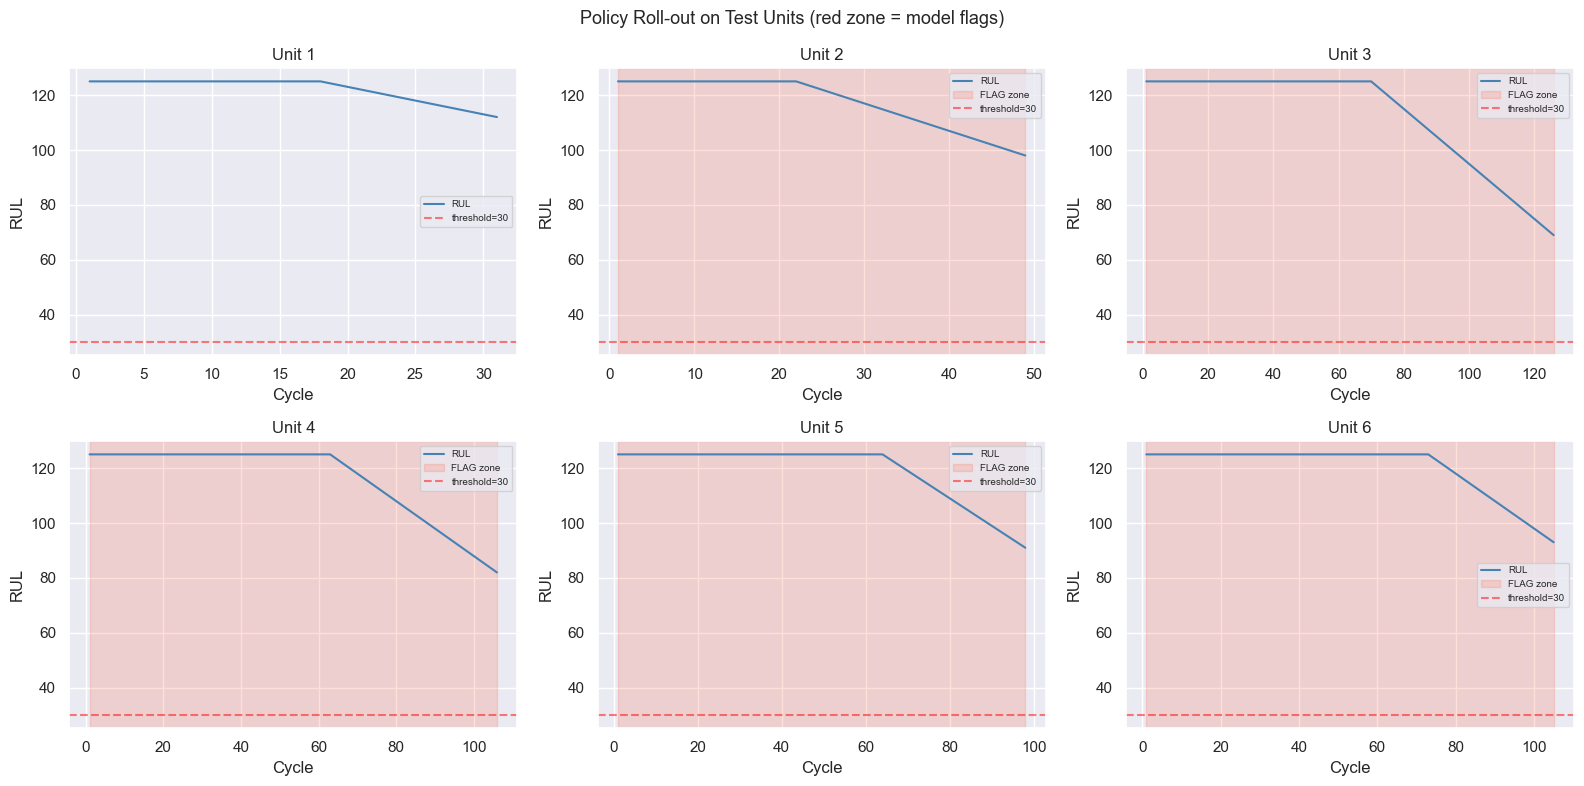

In [10]:
sample_units_test = test['unit'].unique()[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, uid in zip(axes.flat, sample_units_test):
    e = test[test['unit'] == uid].reset_index(drop=True)
    ax.plot(e['cycle'], e['true_RUL'], label='RUL', color='steelblue')
    flag_cycles = e[e['pred_action'] == 1]['cycle']
    if len(flag_cycles):
        ax.axvspan(flag_cycles.min(), flag_cycles.max(),
                   alpha=0.2, color='tomato', label='FLAG zone')
    ax.axhline(FLAG_THRESHOLD, color='red', linestyle='--', alpha=0.5,
               label=f'threshold={FLAG_THRESHOLD}')
    ax.set(title=f'Unit {uid}', xlabel='Cycle', ylabel='RUL')
    ax.legend(fontsize=7)

plt.suptitle('Policy Roll-out on Test Units (red zone = model flags)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Export Model for Comparison with DQN

In [11]:
import pickle
import joblib

# Create export package with all necessary components for inference
model_export = {
    'model_type': 'tabular_q_learning',
    'Q_table': Q,
    'state_dim': 1,  # Single health index
    'n_actions': N_ACTIONS,
    'n_states': N_STATES,
    'rul_cap': RUL_CAP,
    'flag_threshold': FLAG_THRESHOLD,
    'live_sensors': LIVE_SENSORS,
    'pca': pca,
    'scaler': scaler,
    'hyperparameters': {
        'alpha': ALPHA,
        'gamma': GAMMA,
        'epsilon': EPSILON,
        'n_epochs': N_EPOCHS,
        'rolling_window': W,
    }
}

# Save as pickle
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

model_path = models_dir / 'q_learning_fd001.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model_export, f)

print(f'✅ Q-Learning model exported to: {model_path}')
print(f'\nModel metadata:')
print(f'  - Type: {model_export["model_type"]}')
print(f'  - States: {model_export["n_states"]}')
print(f'  - Actions: {model_export["n_actions"]}')
print(f'  - Q-table shape: {Q.shape}')
print(f'  - Training epochs: {model_export["hyperparameters"]["n_epochs"]}')


✅ Q-Learning model exported to: ..\models\q_learning_fd001.pkl

Model metadata:
  - Type: tabular_q_learning
  - States: 20
  - Actions: 2
  - Q-table shape: (20, 2)
  - Training epochs: 50


### Load and Use Saved Model

In [12]:
# Example: load the model to make predictions on new data
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

# To use on new data:
# 1. Preprocess: apply rolling average, normalize with scaler, compute health with PCA
# 2. Discretize health to state: state = int(health * (n_states - 1))
# 3. Get action: action = loaded_model['Q_table'][state].argmax()

print('✅ Model loaded successfully!')
print(f'\nTo use in app.py or comparison:')
print(f'  1. Open {model_path}')
print(f'  2. Extract Q_table and hyperparameters')
print(f'  3. Use pca and scaler for preprocessing new data')


✅ Model loaded successfully!

To use in app.py or comparison:
  1. Open ..\models\q_learning_fd001.pkl
  2. Extract Q_table and hyperparameters
  3. Use pca and scaler for preprocessing new data
